# Agenda

Ada Boost

Gradient Boost

XGBoost (Extreme Gradient)

LightGBM

XGBoost vs RandomForest

Comparision of all ML models on different datasets

Inferences of the experiments

# Ada Boost

Adaptive Boosting combines a lot of weak learners to make classifications. The weak learners are called as stumps (decision tree with 1 node and 2 branch). 


<b> Step 1: Initial Model (B1) </b>

The dataset consists of multiple data points (red, blue and green circles).

Equal weight is assigned to each data point.

The first weak classifier (stump) attempts to create a decision boundary.

n data points are wrongly classified.

<b> Step 2: Adjusting Weights (B2) </b>

The misclassified points from B1 are assigned higher weights.

A new classifier is trained with a refined decision boundary focusing more on the previously misclassified points.

Some previously misclassified points are now correctly classified.

n-2 data points are wrongly classified.

<b> Step 3: Further Adjustment (B3) </b>

The newly misclassified points from B2 receive higher weights to ensure better classification.

The classifier adjusts again using an improved decision boundary and 4 data points remain misclassified.

Each new model focuses on what the earlier models struggled with, refining the decision boundaries gradually.

<b> Step 4: Final Strong Model (B4 - Ensemble Model) </b>

The final ensemble classifier combines B1, B2 and B3 to get strengths of all weak classifiers.

Weighted voting : The final AdaBoost model takes a weighted vote from all weak learners — good models get more say. Each weak learner's vote is weighted by its accuracy. The combined “team” achieves high accuracy and generalization.

By aggregating multiple models the ensemble model achieves higher accuracy than any individual weak model.

This procedure is continued and models are added until either the complete training data set is predicted correctly or predefined number of iterations is reached.

<img src="./images/ada_boost_1.png" alt="sample" width="1000"/>

<img src="./images/ada_boost_2.png" alt="sample" width="1000"/>

<img src="./images/ada_boost_3.jpg" alt="sample" width="1000"/>

# Gradient Boosting

Gradient boosting is a powerful ensemble machine learning technique that builds a strong predictive model by combining a series of weaker models, typically decision trees. The core idea is to iteratively train new models that correct the mistakes made by the previous ones.

The "gradient" in its name comes from the fact that it uses a gradient descent algorithm to minimize the errors (or "residuals") of the combined model.

### How the algorithm works 


1)  Initial prediction: The process starts with a single, simple model as an initial prediction. For a regression task, this is typically the mean of the target variable from the training data.

2)  Calculate residuals: The algorithm then calculates the residual (gradient of loss) for each data point by subtracting the current prediction from the actual target value.

3)  Train a weak learner: A new, simple model (a "weak learner"), usually a shallow decision tree (not a stump like Ada Boost), is trained to predict these residuals. This new model learns to find patterns in the mistakes of the previous model.

4)  Combine and update: The predictions from this new weak learner are scaled down by a small value called the learning rate (η) and then added to the overall ensemble model. The learning rate controls how much the new model's predictions contribute, helping to prevent overfitting.

5)  Iterate and improve: Steps 2–4 are repeated for a fixed number of iterations or until the overall error stops decreasing. With each new tree, the ensemble model becomes progressively more accurate as it corrects the remaining errors. 



<img src="./images/gradient_descent.webp" alt="sample" width="1000"/>

### Example walkthrough (for regression)

Imagine you are predicting house prices based on features like size and age.

<b> Iteration 1: </b>

Initial model: The first prediction is simply the average house price from the training data, say $300,000.

Residuals: For a house actually worth $400,000, the residual is $100,000 ($400,000 - $300,000). For a house worth $250,000, the residual is -$50,000 ($250,000 - $300,000).

New tree: A decision tree is trained specifically to predict these residuals ($100,000, -$50,000, etc.).

Update: The new tree's predictions are scaled and added to the initial model. The overall prediction for the first house might become $300,000 + η * ($100,000).


<b> Iteration 2: </b>

New residuals: The algorithm recalculates the residuals based on the updated predictions from the first iteration. The new residuals are now smaller.

New tree: A second decision tree is trained to predict these smaller, remaining residuals.

Update: This second tree's scaled predictions are added to the updated model from the first iteration. 

This process continues, with each new tree correcting the errors of the entire ensemble up to that point. The final prediction for a new data point is the sum of the initial prediction and the scaled predictions of all the trees. 


### How it works for classification


<b> Step 1: Start with a simple guess </b>

The model begins with a single number as its first prediction — not from data patterns, just a basic average guess.

For binary classification, it starts with the log-odds of the positive class - 

log(p / (1−p))

Log-odds just means: how strongly do we believe something is spam vs. not spam.

If p = 0.5 → log(0.5/0.5) = 0 → we’re neutral (50-50 chance).

If p = 0.8 → log(0.8/0.2) = +1.39 → leaning toward spam.

If p = 0.2 → log(0.2/0.8) = −1.39 → leaning toward not spam.

So initially, every email gets the same neutral score.

<b> Step 2: Compute the residuals (errors) </b>

The model checks how far off its current log-odds predictions are from the actual labels (spam/not spam).

These “errors” are not simple differences (or residuals in linear regression) — they’re gradients of the loss function (log loss), showing the direction and magnitude to move predictions to reduce error.

👉 Think of it like a compass pointing the model which way to move to improve classification accuracy.

<b> Step 3: Fit a small decision tree (a weak learner) to the residuals </b>

A small tree (like a “stump”) is trained to predict these gradients (errors).

It doesn’t predict the class directly — it predicts how to adjust the current prediction for each data point.

<b> Step 4: Update predictions </b>

For each data point, the model updates its current log-odds prediction by adding the output from the new tree (scaled by a small learning rate, say 0.1).

New log-odds = Old log-odds + (learning_rate × tree_output)

👉 This is why it’s called “gradient boosting” — you’re boosting (improving) predictions in the direction of the negative gradient.

<b> Step 5: Convert log-odds to probability </b>

After updating, you convert log-odds back into probabilities:

p = 1 / (1 + exp(-log_odds))

That gives you the probability of being in the “spam” class

<b> Step 6: Repeat the process </b>

You compute new residuals (gradients),

Train another tree,

Add its predictions to the existing model (log-odds),

Convert to probabilities again.


After many such rounds, the model becomes extremely accurate —
each small tree incrementally fixes what the previous ones missed.

### Key components of gradient boosting


Weak learners: The base models are simple, low-complexity models, most often shallow decision trees. By themselves, they are only slightly better than random guessing.

Additive training: The model is built sequentially by adding new weak learners one at a time. Previous models are not altered.

Learning rate (shrinkage): A constant factor applied to the output of each new tree. A smaller learning rate means more trees are needed, but it helps prevent overfitting and improves the model's generalization performance. 

Loss function: Gradient boosting requires a differentiable loss function to measure the error. This allows it to work with various types of problems, from regression (e.g., Mean Squared Error) to classification (e.g., Log-Loss).

# XGBoost (Extreme Boosting algorithm)

### Classification and the loss function

When XGBoost is doing classification (say, spam vs. not spam), it needs a way to measure how wrong its current predictions are.

That’s what a loss function does — it’s like a “mistake meter.”

For two classes, it uses binary cross-entropy (also called log loss).

For multiple classes (e.g., cat/dog/horse), it uses multinomial cross-entropy.

👉 In simple terms:
It compares the predicted probabilities (e.g., 0.8 spam, 0.2 not spam) with the real answers (1 for spam, 0 for not spam) and gives a score — lower is better.

### Boosting — fixing mistakes step-by-step

Like Gradient Boosting, XGBoost builds trees one after another, each one trying to fix the mistakes made by the previous trees.

Each new tree learns where the model is going wrong and nudges the predictions in the right direction.

### Standard Gradient Boosting uses only the first derivative

Now, think of the loss function (the “mistake curve”) as a smooth hill — you want to reach the bottom where the error is lowest.

The first derivative (gradient) tells you the slope — which direction to move to reduce your error.

Standard gradient boosting uses only this slope — it knows which way to go, but not how far or how curved the path is.

👉 So it’s like walking downhill just following the steepest direction.


### XGBoost goes one step further — it also uses the second derivative (Hessian)

The second derivative (Hessian) tells you how curved the hill is — whether it’s gently sloping or steep.

If the curve is steep → take a small step (to avoid overshooting).

If the curve is gentle → take a bigger step (you can move faster).

👉 So, XGBoost doesn’t just know which way to go — it also knows how big a step to take in each direction!

That’s what makes it more accurate, stable, and faster to converge than ordinary gradient boosting.

### How this helps build better trees

When XGBoost builds each decision tree:

It doesn’t just use “how wrong” each prediction is (gradient).

It also looks at how sensitive that wrongness is (Hessian).

This allows it to make smarter splits — choosing the best thresholds and features in a way that reduces error most efficiently.


### Simple Analogy

Imagine you’re trying to roll a ball down to the bottom of a hill (the lowest error):

Gradient Boosting: You only know which direction is downhill. You move slowly and adjust often.

XGBoost: You know both the slope and the curvature of the hill — so you can take smarter, faster, and safer steps toward the bottom.

That’s why XGBoost trains faster, more accurately, and with better stability.

# Light GBM (Light Gradient Boosted Machines)

Both XGBoost and LightGBM are advanced Gradient Boosting frameworks — they both build trees one by one to fix errors and improve accuracy.

They produce very similar results,

but ⚡ LightGBM (Light Gradient Boosted Machine) is usually much faster, especially on large datasets.


LightGBM can split work across multiple cores and machines more efficiently, using less memory.

LightGBM keeps important data points (large gradients) and randomly drops easy ones — it still learns well but with fewer samples → faster training.

Imagine two workers sorting a pile of stones by size:

XGBoost checks every single stone carefully and sorts layer by layer — very accurate but slow.

LightGBM first groups stones into size buckets (bins) — small, medium, large — and only focuses on the ones that are hardest to classify. It ignores the easy ones temporarily and works where mistakes are biggest.

Result: It finishes sorting much faster and with almost the same accuracy.

On big datasets, LightGBM can be 10–20× faster than XGBoost.

On small datasets, the difference is smaller (sometimes even similar).

Accuracy is often just as good or sometimes slightly better.


XGBoost is like a careful craftsman (level-wise growth) — accurate but slow.

LightGBM is like a smart engineer (leaf-wise growth) — uses shortcuts and clever tricks to get the same job done much faster.

<img src="./images/light_gbm.png" alt="sample" width="1000"/>

# Code demo - XGBoost vs RandomForest


=== Random Forest ===
Accuracy : 0.9580
Precision: 0.9565
Recall   : 0.9778
F1-score : 0.9670
ROC-AUC  : 0.9949

Classification Report:
              precision    recall  f1-score   support

           0     0.9608    0.9245    0.9423        53
           1     0.9565    0.9778    0.9670        90

    accuracy                         0.9580       143
   macro avg     0.9587    0.9512    0.9547       143
weighted avg     0.9581    0.9580    0.9579       143


=== XGBoost ===
Accuracy : 0.9650
Precision: 0.9570
Recall   : 0.9889
F1-score : 0.9727
ROC-AUC  : 0.9950

Classification Report:
              precision    recall  f1-score   support

           0     0.9800    0.9245    0.9515        53
           1     0.9570    0.9889    0.9727        90

    accuracy                         0.9650       143
   macro avg     0.9685    0.9567    0.9621       143
weighted avg     0.9655    0.9650    0.9648       143



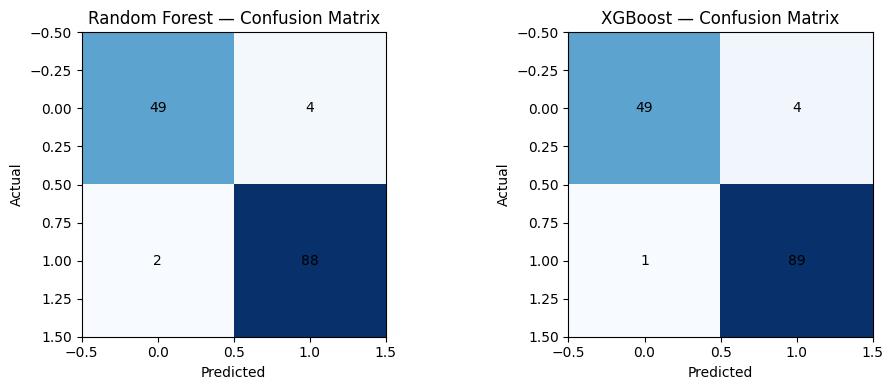

<Figure size 600x500 with 0 Axes>

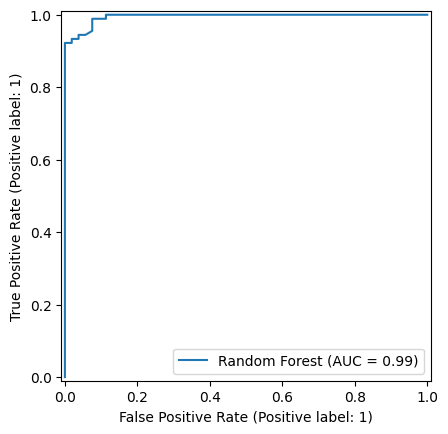

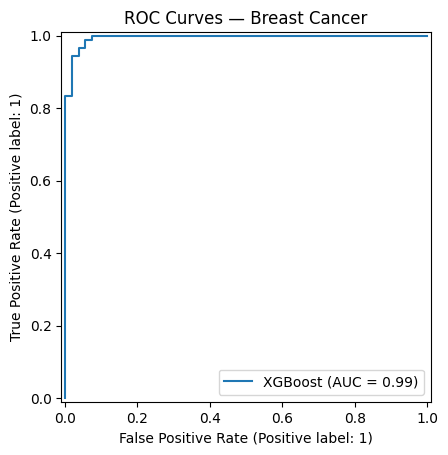


=== Summary (Test Set) ===
               Accuracy  Precision  Recall      F1  ROC-AUC
Random Forest     0.958     0.9565  0.9778  0.9670   0.9949
XGBoost           0.965     0.9570  0.9889  0.9727   0.9950


In [1]:
# Random Forest vs XGBoost on Breast Cancer (real dataset)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay
)
from sklearn.ensemble import RandomForestClassifier

# If needed: pip install xgboost
from xgboost import XGBClassifier

# 1) Load real dataset (binary: malignant vs benign)
data = load_breast_cancer(as_frame=True)
X = data.data
y = pd.Series(data.target, name="target")  # 0 = malignant, 1 = benign

# 2) Train/test split (stratified to keep class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Optional: class balance info
neg = (y_train == 0).sum()  # malignant
pos = (y_train == 1).sum()  # benign
scale_pos_weight = neg / pos  # for XGB (handles imbalance slightly)

# 3) Models
rf = RandomForestClassifier(
    n_estimators=300,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight
)

# 4) Fit
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)

# 5) Predictions (labels + probabilities for ROC-AUC)
rf_pred = rf.predict(X_test)
xgb_pred = xgb.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]
xgb_proba = xgb.predict_proba(X_test)[:, 1]

# 6) Metric helper
def evaluate(name, y_true, y_pred, y_proba):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba)
    print(f"\n=== {name} ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4))
    return acc, prec, rec, f1, auc

rf_metrics  = evaluate("Random Forest", y_test, rf_pred, rf_proba)
xgb_metrics = evaluate("XGBoost",       y_test, xgb_pred, xgb_proba)

# 7) Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(10,4))
for ax, (name, yhat) in zip(axes, [("Random Forest", rf_pred), ("XGBoost", xgb_pred)]):
    cm = confusion_matrix(y_test, yhat)
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(f"{name} — Confusion Matrix")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, str(v), ha="center", va="center")
plt.tight_layout(); plt.show()

# 8) ROC curves
plt.figure(figsize=(6,5))
RocCurveDisplay.from_predictions(y_test, rf_proba, name="Random Forest")
RocCurveDisplay.from_predictions(y_test, xgb_proba, name="XGBoost")
plt.title("ROC Curves — Breast Cancer")
plt.show()

# 9) Side-by-side metric table
summary = pd.DataFrame(
    [rf_metrics, xgb_metrics],
    columns=["Accuracy","Precision","Recall","F1","ROC-AUC"],
    index=["Random Forest","XGBoost"]
)
print("\n=== Summary (Test Set) ===")
print(summary.round(4))

# Run all models on different datasets

### BreastCancer dataset

In [2]:
# Import libraries
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (important for distance-based models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "SVM (RBF Kernel)": SVC(kernel='rbf', probability=True),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Naive Bayes": GaussianNB(),
    "XGBoost": XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    )
}

# Train and evaluate
results = []
for name, model in models.items():
    if name in ["SVM (RBF Kernel)", "KNN (k=5)", "Logistic Regression"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    results.append((name, acc))
    print(f"\n🔹 {name}")
    print(classification_report(y_test, y_pred, target_names=data.target_names))

# Summary table
results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
print("\n===== MODEL COMPARISON =====")
print(results_df.sort_values(by="Accuracy", ascending=False))

/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: over


🔹 Logistic Regression
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


🔹 SVM (RBF Kernel)
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


🔹 KNN (k=5)
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg      

### Inferences

The Breast Cancer dataset (sklearn.datasets.load_breast_cancer()) is almost linearly separable — its features (like mean radius, smoothness, etc.) form a near-linear boundary between benign and malignant classes.

Logistic Regression (a linear model) is perfectly suited to such datasets.

XGBoost, by contrast, learns non-linear tree ensembles, which can slightly overfit or “overcomplicate” a simple boundary → marginally lower test accuracy.

XGBoost shines on large, complex datasets (10K+ rows).

So on small, clean datasets → simpler models often generalize better.


### Wine quality dataset

In [3]:
# Wine Quality (3–8) — Multi-class benchmark without GridSearchCV
# Models: LogisticRegression, SVM, KNN, DecisionTree, RandomForest, NaiveBayes, XGBoost

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

# 1) Load Wine Quality (Red) dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=";")

X = df.drop(columns=["quality"])
y_raw = df["quality"]                       # classes are {3,4,5,6,7,8}

# Label-encode target -> {0..K-1}, keep names for reporting
le = LabelEncoder()
y = le.fit_transform(y_raw)                  # e.g., 3->0, 4->1, ..., 8->5
class_names = [str(c) for c in le.classes_]  # ["3","4","5","6","7","8"]

# 2) Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 3) Scale for models that need it
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# 4) Define models (XGB directly in dict, no num_class)
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=500, multi_class="multinomial"
    ),
    "SVM (RBF)": SVC(kernel="rbf", random_state=42),
    "KNN (k=7)": KNeighborsClassifier(n_neighbors=7),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Naive Bayes": GaussianNB(),
    "XGBoost": XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        n_estimators=200,
        learning_rate=0.1,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        random_state=42,
        verbosity=0,
    ),
}

# 5) Train & evaluate
results = []
scale_needed = {"Logistic Regression", "SVM (RBF)", "KNN (k=7)"}

for name, model in models.items():
    Xtr, Xte = (X_train_sc, X_test_sc) if name in scale_needed else (X_train, X_test)
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)

    acc = accuracy_score(y_test, y_pred)
    f1m = f1_score(y_test, y_pred, average="macro")
    results.append((name, acc, f1m))

    print(f"\n===== {name} =====")
    print(classification_report(y_test, y_pred, target_names=class_names))

# 6) Summary
summary = pd.DataFrame(results, columns=["Model", "Accuracy", "F1_macro"])
print("\n===== MODEL COMPARISON =====")
print(summary.sort_values(by="F1_macro", ascending=False))

/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.


===== Logistic Regression =====
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.62      0.73      0.67       136
           6       0.54      0.61      0.57       128
           7       0.71      0.30      0.42        40
           8       0.00      0.00      0.00         3

    accuracy                           0.59       320
   macro avg       0.31      0.27      0.28       320
weighted avg       0.57      0.59      0.57       320


===== SVM (RBF) =====
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.65      0.76      0.70       136
           6       0.58      0.65      0.61       128
           7       0.78      0.35      0.48        40
           8       0.00      0.00      0.00         3

    accuracy         

/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo


===== XGBoost =====
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.50      0.09      0.15        11
           5       0.72      0.74      0.73       136
           6       0.63      0.70      0.66       128
           7       0.73      0.60      0.66        40
           8       0.50      0.33      0.40         3

    accuracy                           0.68       320
   macro avg       0.51      0.41      0.43       320
weighted avg       0.67      0.68      0.67       320


===== MODEL COMPARISON =====
                 Model  Accuracy  F1_macro
6              XGBoost  0.678125  0.434579
4        Random Forest  0.668750  0.399338
3        Decision Tree  0.606250  0.393931
5          Naive Bayes  0.571875  0.324282
1            SVM (RBF)  0.625000  0.298956
2            KNN (k=7)  0.593750  0.291516
0  Logistic Regression  0.590625  0.277628


/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

### Inferences

XGBoost performed really well than LogisticRegression. Why ?

The target variable (quality, typically 3–8) depends on chemical properties like:

fixed acidity, volatile acidity, residual sugar, chlorides, sulphates, alcohol, etc.

These relationships are non-linear and interactive.

Example:

Moderate acidity may increase quality up to a point, then decrease it beyond a threshold (a non-linear curve).

High alcohol + low volatile acidity → good quality, but the combination matters (interaction).

So the relationship between predictors and quality score isn’t a straight line — it’s curved and multidimensional.

How do you derive this relationship ? Through EDA !!!